In [14]:
import numpy as np
import math
from collections import deque

def fit_gpd_params(excesses):
    """
    Simple method-of-moments approach for GPD shape & scale.
    """
    mean_ex = np.mean(excesses)
    var_ex  = np.var(excesses)
    if var_ex <= 0:
        var_ex = 1e-6

    shape = 0.5*((mean_ex**2)/var_ex - 1.0)
    scale = 0.5*mean_ex*((mean_ex**2)/var_ex + 1.0)

    if scale <= 0:
        scale = 1e-6
    return shape, scale

def initialize_dynamic_threshold_optimized(
    initial_data,
    base_quantile=0.90,
    min_window_size=30,
    buffer_maxlen=1000
):
    # sort initial data, find base threshold
    sorted_data = np.sort(initial_data)
    idx = int(base_quantile * len(sorted_data))
    if idx >= len(sorted_data):
        idx = len(sorted_data) - 1
    t0 = sorted_data[idx]

    data_buffer = deque(initial_data, maxlen=buffer_maxlen)

    # compute initial shape/scale
    excesses = [x - t0 for x in initial_data if x > t0]
    if len(excesses) < min_window_size:
        shape = 0.0
        scale = np.std(initial_data) if len(initial_data) > 1 else 1.0
    else:
        shape, scale = fit_gpd_params(excesses)

    dyn_state = {
        'threshold': t0,       # base threshold t0
        'shape': shape,
        'scale': scale,
        'data_buffer': data_buffer,
        'min_window_size': min_window_size,
        'update_counter': 0,   # how many new points we have processed
        'update_frequency': 10 # re-fit GPD every K points, you can tune this
    }
    return dyn_state

def update_threshold_gpd_optimized(
    dist_value,
    dyn_state,
    high_quantile=0.999
):
    """
    Add dist_value to buffer, possibly re-fit GPD shape/scale every K steps,
    then compute the final threshold using the GPD quantile formula.
    """
    t0     = dyn_state['threshold']
    shape  = dyn_state['shape']
    scale  = dyn_state['scale']
    buffer = dyn_state['data_buffer']
    min_ws = dyn_state['min_window_size']
    upd_freq = dyn_state['update_frequency']

    buffer.append(dist_value)
    dyn_state['update_counter'] += 1

    # Re-fit only every 'upd_freq' steps
    if dyn_state['update_counter'] % upd_freq == 0:
        all_data = np.array(buffer)
        # pick new baseline threshold as 90th percentile
        new_t0 = np.percentile(all_data, 90)

        new_excesses = all_data[all_data > new_t0] - new_t0
        if len(new_excesses) >= min_ws:
            shape, scale = fit_gpd_params(new_excesses)

        dyn_state['threshold'] = new_t0
        dyn_state['shape']     = shape
        dyn_state['scale']     = scale
    else:
        new_t0 = t0

    # now compute the final drift threshold
    xi = shape
    beta = scale
    if abs(xi) < 1e-12:
        # near 0 => exponential limit
        final_thr = new_t0 + beta * math.log(1.0/(1.0 - high_quantile))
    else:
        one_m_q = 1.0 - high_quantile
        inside = (one_m_q)**(-xi) - 1.0
        if inside < 0:
            inside = 0.0
        final_thr = new_t0 + beta/xi*inside

    return final_thr


In [15]:
import os
import random
import time  # <-- Import time
import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from sklearn.decomposition import PCA
from collections import defaultdict
from scipy.stats import wasserstein_distance

###############################################################################
# Arguments
###############################################################################
args = {
    "models": [
        "nlpaueb/sec-bert-base",
        "bert-base-uncased"
    ],
    "datasets": [
        {
            "name": "yelp_review_full",
            "config": None,
            "split": "train",
            "text_column": "text"
        },
        {
            "name": "wikitext",
            "config": "wikitext-2-raw-v1",
            "split": "train",
            "text_column": "text"
        },
        {
            "name": "ag_news",
            "config": None,
            "split": "train",
            "text_column": "text"
        },
    ],
    "max_texts": 1000,
    "batch_size": 64,
    "drift_strengths": [0.0, 0.25, 0.5, 0.75, 1.0],
    "pca_components": 2,
    "output_dir": "data-analysis/data",
    "hist_bins": 30,
    "num_seeds": 3,
    "kl_eps": 1e-12,
    "use_adaptive_gamma": True
}
os.makedirs(args["output_dir"], exist_ok=True)

###############################################################################
# Utility Functions
###############################################################################
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def batch_generator(data, batch_size=32):
    for i in range(0, len(data), batch_size):
        yield data[i : i + batch_size]

def extract_cls_embeddings(model, tokenizer, texts, device):
    encodings = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )
    input_ids = encodings["input_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
    return cls_embeddings.cpu().numpy()

def introduce_gradual_drift(text_list, fraction_shuffle=0.5):
    """
    Simple 'drift' function that shuffles a fraction of words in each text.
    """
    new_texts = []
    for txt in text_list:
        words = txt.split()
        if len(words) < 2:
            new_texts.append(txt)
            continue
        k = int(len(words) * fraction_shuffle)
        if k < 1:
            new_texts.append(txt)
            continue
        indices = list(range(len(words)))
        random.shuffle(indices)
        shuffle_indices = indices[:k]
        to_shuffle = [words[i] for i in shuffle_indices]
        random.shuffle(to_shuffle)
        for i, idx in enumerate(shuffle_indices):
            words[idx] = to_shuffle[i]
        new_texts.append(" ".join(words))
    return new_texts

###############################################################################
# 1) Building Distribution Histograms in 2D
###############################################################################
def build_2d_hist(embs_2d, bins=30):
    """
    Given Nx2 embeddings, build a 2D histogram *as a probability distribution*.
    We turn off 'density=True', then manually normalize so that it sums to 1.
    """
    hist, xedges, yedges = np.histogram2d(
        embs_2d[:, 0],
        embs_2d[:, 1],
        bins=bins,
        density=False
    )
    # Normalize so sum of all bins = 1
    hist = hist / hist.sum()
    return hist, xedges, yedges

###############################################################################
# 2) Common Distribution-Based Distances or Divergences
###############################################################################
def safe_prob(p, eps=1e-12):
    """
    Utility to avoid zeros for logs or divisions.
    """
    return np.maximum(p, eps)

def kl_divergence(p, q, kl_eps=1e-12):
    """
    Discrete KL Divergence:
        KL(P||Q) = sum_i p_i * log( p_i / q_i )
    """
    p_ = safe_prob(p, eps=kl_eps)
    q_ = safe_prob(q, eps=kl_eps)
    return np.sum(p_ * np.log(p_ / q_))

def js_divergence(p, q, kl_eps=1e-12):
    """
    Jensen-Shannon Divergence:
        JS(P||Q) = 0.5 * KL(P || M) + 0.5 * KL(Q || M)
        where M = 0.5*(P+Q)
    """
    p_ = safe_prob(p, eps=kl_eps)
    q_ = safe_prob(q, eps=kl_eps)
    m_ = 0.5 * (p_ + q_)
    return 0.5 * kl_divergence(p_, m_, kl_eps=kl_eps) + 0.5 * kl_divergence(q_, m_, kl_eps=kl_eps)

def hellinger_distance(p, q, kl_eps=1e-12):
    """
    Hellinger distance for discrete distributions:
        H^2(P, Q) = 1 - sum_i sqrt(p_i * q_i)
        => H(P, Q) = sqrt( H^2(...) )
    """
    p_ = np.sqrt(safe_prob(p, eps=kl_eps))
    q_ = np.sqrt(safe_prob(q, eps=kl_eps))
    return np.sqrt(np.sum((p_ - q_)**2) / 2.0)

def bhattacharyya_distance(p, q, kl_eps=1e-12):
    """
    Bhattacharyya distance:
        d_B(P, Q) = -ln( sum_i sqrt(p_i q_i) )
    """
    bc = np.sum(np.sqrt(safe_prob(p, eps=kl_eps) * safe_prob(q, eps=kl_eps)))
    return -np.log(bc + 1e-12)  # Prevent log(0)


def compute_2d_hist_distance(baseline_embs, new_embs, measure="js",
                             bins=30, kl_eps=1e-12):
    """
    1) Build 2D histograms with the same bin edges
    2) Compute the specified measure
    """
    # Build histogram for baseline
    hist_p, xedges, yedges = build_2d_hist(baseline_embs, bins=bins)

    # Build histogram for new data using the *same* bin edges
    hist_q_raw, _, _ = np.histogram2d(
        new_embs[:, 0],
        new_embs[:, 1],
        bins=[xedges, yedges],
        density=False
    )
    # Normalize so that hist_q sums to 1 as well
    hist_q = hist_q_raw / hist_q_raw.sum()

    p = hist_p.flatten()
    q = hist_q.flatten()

    # Choose distance measure
    if measure == "kl":
        return kl_divergence(p, q, kl_eps=kl_eps)
    elif measure == "js":
        return js_divergence(p, q, kl_eps=kl_eps)
    elif measure == "hellinger":
        return hellinger_distance(p, q, kl_eps=kl_eps)
    elif measure == "bhattacharyya":
        return bhattacharyya_distance(p, q, kl_eps=kl_eps)
    else:
        raise ValueError(f"Unknown measure: {measure}")

###############################################################################
# 3) Simple MMD Computation (sample-based, no histogram)
###############################################################################
def rbf_kernel(x, y, gamma=1.0):
    x2 = np.sum(x**2, axis=1)[:, None]
    y2 = np.sum(y**2, axis=1)[None, :]
    dist2 = x2 + y2 - 2*np.dot(x, y.T)
    return np.exp(-gamma * dist2)

def compute_mmd(baseline_embs, new_embs, gamma=0.5):
    """
    MMD^2 = E[k(x,x')] + E[k(y,y')] - 2 E[k(x,y)]
    Return sqrt(MMD^2).
    """
    X = baseline_embs
    Y = new_embs
    XX = rbf_kernel(X, X, gamma=gamma)
    YY = rbf_kernel(Y, Y, gamma=gamma)
    XY = rbf_kernel(X, Y, gamma=gamma)
    m = len(X)
    n = len(Y)

    mmd2 = XX.sum() / (m**2) + YY.sum() / (n**2) - 2.0 * XY.sum() / (m*n)
    return np.sqrt(mmd2)

def auto_select_gamma(embs):
    """
    Simple heuristic: use gamma = 1/(2*median_of_pairwise_distance^2).
    """
    # Subsample if needed (for speed)
    sample = embs
    if len(embs) > 500:
        sample = embs[np.random.choice(len(embs), 500, replace=False)]
    dists = []
    for i in range(len(sample)-1):
        dist2 = np.sum((sample[i] - sample[i+1:])**2, axis=1)
        dists.append(dist2)
    dists = np.concatenate(dists)
    median_dist2 = np.median(dists)
    if median_dist2 <= 0.0:
        median_dist2 = 1e-6
    return 1.0 / (2.0 * median_dist2)

###############################################################################
# 4) Multi-D Wasserstein (Sum of 1D)
###############################################################################
def compute_wasserstein_1D_per_dim(baseline_embs, new_embs):
    d = baseline_embs.shape[1]
    w_sum = 0.0
    for i in range(d):
        w_sum += wasserstein_distance(baseline_embs[:, i], new_embs[:, i])
    return w_sum

def run_experiment_single_seed(seed, args):
    set_seed(seed)

    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")

    print(f"[Seed={seed}] Using device:", device)
    results = defaultdict(list)
    # We'll also store a 'drift_detection' result
    drift_detection_flags = defaultdict(list)

    for dataset_info in args["datasets"]:
        dataset_name  = dataset_info["name"]
        dataset_config = dataset_info["config"]
        dataset_split = dataset_info["split"]
        text_col      = dataset_info["text_column"]

        print(f"[Seed={seed}] === Loading dataset: {dataset_name} ===")
        ds = load_dataset(dataset_name, dataset_config, split=dataset_split)
        texts = list(ds[text_col])
        random.shuffle(texts)
        if args["max_texts"] > 0 and len(texts) > args["max_texts"]:
            texts = texts[: args["max_texts"]]

        half_point = len(texts) // 2
        baseline_texts = texts[:half_point]
        drift_texts    = texts[half_point:]

        for model_name in args["models"]:
            print(f"[Seed={seed}] --- Using Model: {model_name} ---")
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            model = AutoModel.from_pretrained(model_name)
            model.to(device)
            model.eval()

            # 1) baseline embeddings
            baseline_embs = []
            for b in batch_generator(baseline_texts, args["batch_size"]):
                emb_b = extract_cls_embeddings(model, tokenizer, b, device)
                baseline_embs.append(emb_b)
            baseline_embs = np.concatenate(baseline_embs, axis=0)

            # PCA
            pca = PCA(n_components=args["pca_components"])
            pca.fit(baseline_embs)
            baseline_embs_2d = pca.transform(baseline_embs)

            if args["use_adaptive_gamma"]:
                gamma_val = auto_select_gamma(baseline_embs)
            else:
                gamma_val = 0.5

            distribution_measures = ["kl","js","hellinger",
                                     "bhattacharyya","mmd","wasserstein"]

            for measure_name in distribution_measures:
                # -----------------------------------------------------------------
                # We pretend we have a "stream" of drift_strength data points
                # We'll store them in a small list first, e.g. [dist_val_0, dist_val_1, ...].
                # Then we feed them to our GPD-based threshold.
                # -----------------------------------------------------------------

                # We'll create an array that will hold the distance values for each drift strength
                drift_values_for_measure = []

                for drift_strength in args["drift_strengths"]:
                    # create drift
                    drifted_texts = introduce_gradual_drift(drift_texts, fraction_shuffle=drift_strength)

                    # compute new embeddings
                    new_embs = []
                    for b in batch_generator(drifted_texts, args["batch_size"]):
                        emb_b = extract_cls_embeddings(model, tokenizer, b, device)
                        new_embs.append(emb_b)
                    new_embs = np.concatenate(new_embs, axis=0)
                    new_embs_2d = pca.transform(new_embs)

                    # measure
                    if measure_name in ["kl","js","hellinger","bhattacharyya"]:
                        dist_val = compute_2d_hist_distance(
                            baseline_embs_2d,
                            new_embs_2d,
                            measure=measure_name,
                            bins=args["hist_bins"],
                            kl_eps=args["kl_eps"]
                        )
                    elif measure_name == "mmd":
                        dist_val = compute_mmd(baseline_embs, new_embs, gamma=gamma_val)
                    elif measure_name == "wasserstein":
                        dist_val = compute_wasserstein_1D_per_dim(baseline_embs_2d, new_embs_2d)
                    else:
                        dist_val = None

                    drift_values_for_measure.append(dist_val)
                    # store raw distance
                    key = (dataset_name, model_name, measure_name, drift_strength)
                    results[key].append(dist_val)

                # Now we have 5 data points (one per drift_strength). We'll show
                # how to do dynamic threshold detection with them in order:
                #    drift_values_for_measure[0], drift_values_for_measure[1], ...
                # This is not truly streaming, but an example.

                # Step 0: warmup with first data
                warmup_data = drift_values_for_measure[:2]  # e.g. 2 points for warmup
                dyn_state = initialize_dynamic_threshold_optimized(
                    warmup_data,
                    base_quantile=0.90,
                    min_window_size=3,     # small for demonstration
                    buffer_maxlen=10
                )

                drift_flags_local = []
                for idx, dist_val in enumerate(drift_values_for_measure):
                    # from the second point onward, do update
                    if idx < 2:
                        # warmup, no detection
                        drift_flags_local.append(False)
                        continue
                    # get final threshold
                    final_thr = update_threshold_gpd_optimized(dist_val, dyn_state, high_quantile=0.999)
                    # check drift
                    is_drift = (dist_val > final_thr)
                    drift_flags_local.append(is_drift)

                # store the drift flags in drift_detection_flags
                # We'll store them under the same key but with a suffix
                key_drift = (dataset_name, model_name, measure_name, "drift_flags")
                drift_detection_flags[key_drift].append(drift_flags_local)

    return results, drift_detection_flags

def collect_data_multiple_seeds(args):
    all_results = defaultdict(list)
    all_drifts  = defaultdict(list)
    for seed in range(args["num_seeds"]):
        seed_results, seed_drifts = run_experiment_single_seed(seed, args)
        # merge
        for k, dist_vals in seed_results.items():
            all_results[k].extend(dist_vals)
        for k, drf_vals in seed_drifts.items():
            all_drifts[k].extend(drf_vals)
    print("Data collection + drift detection done!")
    return all_results, all_drifts

# ------------------------------------------------------------------------------
# Now run the new function:
# ------------------------------------------------------------------------------
all_results, all_drifts = collect_data_multiple_seeds(args)

# You can inspect all_drifts to see which points triggered drift
# For example:
for k, v in all_drifts.items():
    print(k, v)


[Seed=0] Using device: mps
[Seed=0] === Loading dataset: yelp_review_full ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=0] --- Using Model: bert-base-uncased ---
[Seed=0] === Loading dataset: wikitext ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=0] --- Using Model: bert-base-uncased ---
[Seed=0] === Loading dataset: ag_news ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=0] --- Using Model: bert-base-uncased ---
[Seed=1] Using device: mps
[Seed=1] === Loading dataset: yelp_review_full ===
[Seed=1] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=1] --- Using Model: bert-base-uncased ---
[Seed=1] === Loading dataset: wikitext ===
[Seed=1] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=1] --- Using Model: bert-base-uncased ---
[Seed=1] === Loading dataset: ag_news ===
[Seed=1] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=1] --- Using Model: bert-base-uncased ---
[Seed=2] Using device: mps
[Seed=2] === Loading dataset: yelp_review_full 

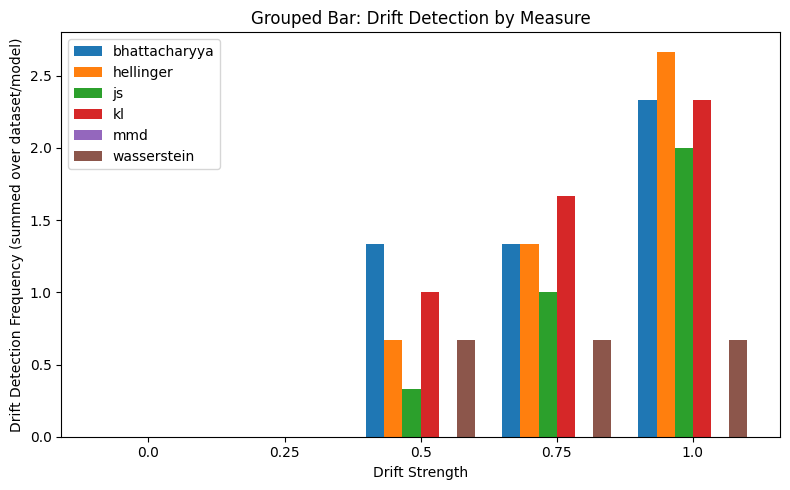

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def plot_drift_grouped_bar(drift_results, drift_strengths):
    """
    Show a grouped bar chart where each group is a drift_strength,
    and each bar in the group is a measure's drift frequency (averaged or summed).
    """
    measures = set()
    # We'll collect the average detection frequency for each measure at each drift_strength
    detection_data = {}
    # detection_data[measure][drift_strength] = average drift frequency

    # 1) Iterate over drift_results keys: (dataset, model, measure, 'drift_flags')
    for key, all_flags in drift_results.items():
        if key[-1] != 'drift_flags':
            continue
        dataset_name, model_name, measure_name, tag = key
        freq = np.mean(all_flags, axis=0)  # shape => [len(drift_strengths)]
        measures.add(measure_name)

        # For demonstration, we accumulate frequencies measure by measure
        # (combining all dataset/model combos).
        # If you want them separate, you can do so by changing the aggregator logic.
        if measure_name not in detection_data:
            detection_data[measure_name] = np.zeros(len(drift_strengths))
        detection_data[measure_name] += freq  # Summation or you could keep a list

    # Because we are summing freq across all dataset/model combos,
    # you might want to divide by the count to get an average.
    # Or just leave it as "sum" to see how often drift is triggered in total.
    # We'll do a naive approach here: just show the sum.

    measure_list = sorted(measures)
    x = np.arange(len(drift_strengths))  # x positions for groups
    width = 0.8 / len(measure_list)      # bar width for each measure

    fig, ax = plt.subplots(figsize=(8,5))
    for i, measure in enumerate(measure_list):
        bars = detection_data[measure]
        offset = (i - len(measure_list)/2) * width + width/2
        ax.bar(x + offset, bars, width, label=measure)

    ax.set_xticks(x)
    ax.set_xticklabels([str(ds) for ds in drift_strengths])
    ax.set_xlabel("Drift Strength")
    ax.set_ylabel("Drift Detection Frequency (summed over dataset/model)")
    ax.set_title("Grouped Bar: Drift Detection by Measure")
    ax.legend()
    plt.tight_layout()
    plt.show()

# After your code that collects `all_drifts`:
# all_results, all_drifts = collect_data_multiple_seeds(args)

# Just call:
plot_drift_grouped_bar(all_drifts, args["drift_strengths"])


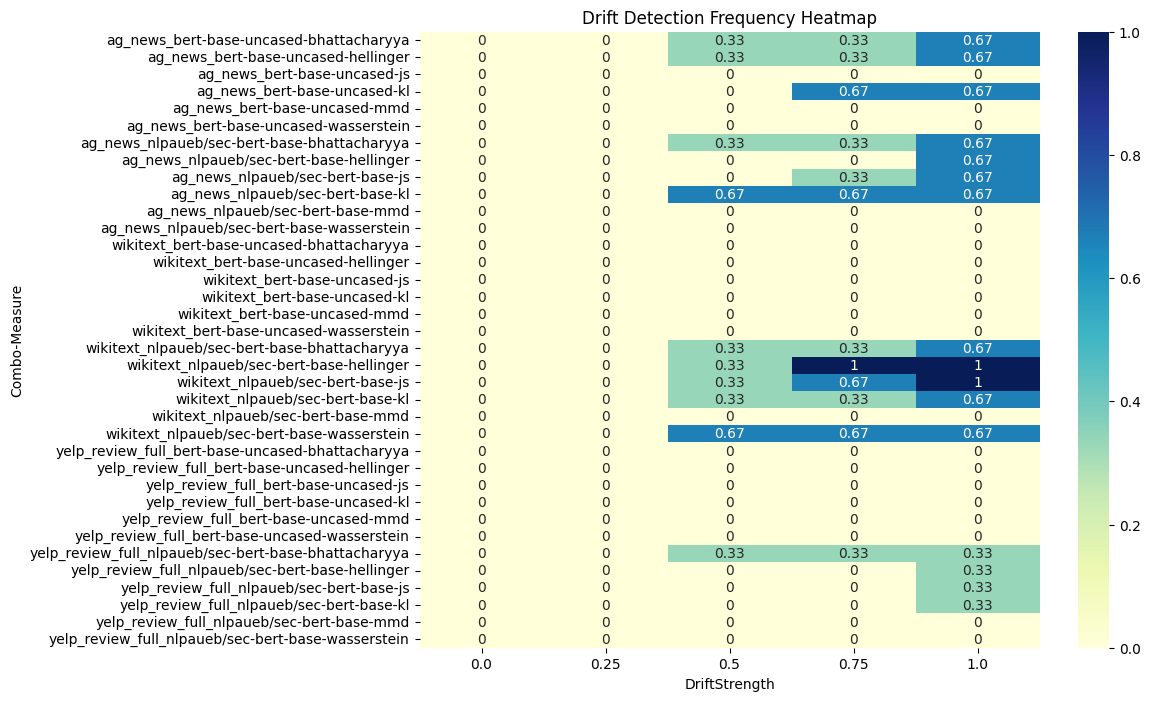

In [17]:
import seaborn as sns

def plot_drift_heatmap(drift_results, drift_strengths):
    # We'll produce a pivot table (df) of average detection freq
    import pandas as pd
    rows = []
    for key, all_flags in drift_results.items():
        # key = (dataset, model, measure, 'drift_flags')
        if key[-1] != 'drift_flags':
            continue
        ds, mdl, measure, _ = key
        freq = np.mean(all_flags, axis=0)  # shape = [len(drift_strengths)]
        # freq[i] = detection frequency at drift_strengths[i]
        for i, ds_val in enumerate(drift_strengths):
            rows.append({
                "Dataset": ds,
                "Model": mdl,
                "Measure": measure,
                "DriftStrength": ds_val,
                "DetectionFreq": freq[i]
            })
    df = pd.DataFrame(rows)

    # Now pick a pivot dimension.
    # Suppose we pivot on measure (rows) vs. drift strength (columns)
    # for a single dataset-model or we group them.
    # We'll have to do it for each dataset-model pair:
    # For demonstration, let's pick just one dataset-model or group them.

    # Let's group dataset & model into one label for demonstration:
    df["Combo"] = df["Dataset"] + "_" + df["Model"]

    # pivot to get measure as rows, drift_strength as columns
    pivot_table = df.pivot_table(
        index=["Combo","Measure"],
        columns="DriftStrength",
        values="DetectionFreq",
        aggfunc='mean'
    )

    # we can create a heatmap from pivot_table
    plt.figure(figsize=(10,8))
    sns.heatmap(pivot_table, annot=True, cmap="YlGnBu")
    plt.title("Drift Detection Frequency Heatmap")
    plt.show()

plot_drift_heatmap(all_drifts, args["drift_strengths"])

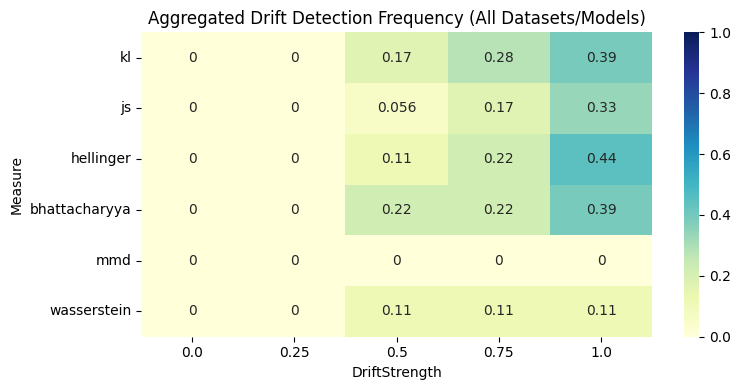

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

def plot_aggregated_six_measures(drift_results, drift_strengths):
    """
    Creates a 6x(len(drift_strengths)) heatmap,
    each row is a measure, each column is drift_strength.
    The cell value is the average drift-detection frequency
    across *all* dataset/model combos for that measure + drift_strength.
    """

    # We want exactly these 6 measures, in this order:
    measure_list = ["kl","js","hellinger","bhattacharyya","mmd","wasserstein"]

    # We'll accumulate: measure -> sum_of_freq[] and a count
    measure2freqSum   = defaultdict(lambda: np.zeros(len(drift_strengths)))
    measure2freqCount = defaultdict(int)

    # 1) Loop over all drift_flags in the results
    for key, all_flags in drift_results.items():
        # key structure: (dataset, model, measure, 'drift_flags')
        if key[-1] != 'drift_flags':
            continue
        measure = key[2]  # e.g. "kl","js", etc.
        # all_flags is shape [num_seeds], each is array [num_strengths]
        # We average across seeds => freqArr shape = [num_strengths]
        freqArr = np.mean(all_flags, axis=0)

        # accumulate into measure2freqSum
        measure2freqSum[measure] += freqArr
        measure2freqCount[measure] += 1

    # 2) Build final matrix: shape (6, len(drift_strengths))
    data_matrix = []
    for measure in measure_list:
        if measure2freqCount[measure] > 0:
            avg_arr = measure2freqSum[measure] / measure2freqCount[measure]
        else:
            # No data for this measure => fill zeros
            avg_arr = np.zeros(len(drift_strengths))
        data_matrix.append(avg_arr)
    data_matrix = np.array(data_matrix)  # shape => (6, len(drift_strengths))

    # 3) Create a nice DataFrame for Seaborn
    df_measures = pd.DataFrame(
        data_matrix,
        index=measure_list,
        columns=[str(s) for s in drift_strengths]
    )

    # 4) Plot heatmap
    plt.figure(figsize=(8,4))
    sns.heatmap(
        df_measures,
        annot=True,
        cmap="YlGnBu",
        vmin=0, vmax=1
    )
    plt.title("Aggregated Drift Detection Frequency (All Datasets/Models)")
    plt.xlabel("DriftStrength")
    plt.ylabel("Measure")
    plt.tight_layout()
    plt.show()

plot_aggregated_six_measures(all_drifts, args["drift_strengths"])